<a href="https://colab.research.google.com/github/Doufoungognon/portfolio/blob/main/%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_%E2%84%963_%D0%9B%D0%B0%D0%B1%D0%BA%D0%B0_%E2%84%961_%D0%9A%D1%81%D0%B0%D0%B2%D1%8C%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## `Лабораторная работа №1`

#### Фамилия, имя: Ксавье

Дата выдачи: <span style="color:red">__02 декабря__</span>.

Срок сдачи: <span style="color:red">__25 декабря__</span>.

Максимальная оценка: __10 баллов__





### `Задание 3. Классификации изображений животных с помощью свёрточной нейронной сети для (5 баллов)`.

**Цель**: Разработать и обучить нейронную сеть для классификации изображений.

Основная задача: реализовать весь пайплан обучения модели и добиться хорошего значения метрики accuracy (> 0.5) на тестовой выборке.

Используется открытый датасет:

Animal Image Dataset (90 Different Animals) — https://www.kaggle.com/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals


**1.** Подготовка данных

Скачайте и распакуйте датасет.

Разделите выборку на обучающую и тестовую части (например, 80 % / 20 %).

Определите преобразования (`transform`) для изображений:

- изменение размера (например, 128×128);

- нормализация;

- при желании — аугментации (отражение, поворот, кроп).

Создайте объекты `torch.utils.data.Dataset` и `DataLoader`.

**2.** Реализуйте свёрточную нейронную сеть с использованием `torch.nn`:

- несколько свёрточных слоёв (Conv2d, ReLU, MaxPool2d);

- полносвязные слои для классификации;

- выходной слой с количеством нейронов, равным числу классов.

**3.** Определите функцию потерь (`CrossEntropyLoss`) и оптимизатор (`Adam` или `SGD`).

Обучите модель в течение 10–20 эпох, выводя на каждой эпохе:

`train_loss`, `train_accuracy`;

`val_loss`, `val_accuracy`.

**4.** Постройте графики изменения потерь (`loss`) и точности (`accuracy`) на обучающей и тестовой выборках.


Выведите несколько примеров изображений из тестового набора с предсказанными классами и истинными метками.



#Шаг 1. Подключить Google Drive

In [ ]:
!pip install kaggle --quiet

Устанавливает пакет kaggle, чтобы код мог автоматически скачать датасет с Kaggle.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Шаг 2. Задать пути под твой архив

In [ ]:
import os

# Базовая папка для работы — та, где уже лежит архив
base_dir = "/content/drive/MyDrive/111/archive"

# Папка с КАРТИНКАМИ (внутренняя animals/animals)
data_dir = "/content/drive/MyDrive/111/archive/animals/animals"

print("base_dir:", base_dir)
print("data_dir:", data_dir)
print("Содержимое base_dir:")
print(os.listdir(base_dir))
print("Содержимое data_dir (несколько классов):")
print(os.listdir(data_dir)[:10])


base_dir: /content/drive/MyDrive/111/archive
data_dir: /content/drive/MyDrive/111/archive/animals/animals
Содержимое base_dir:
['name of the animals.txt', 'animals']
Содержимое data_dir (несколько классов):
['antelope', 'badger', 'bat', 'bear', 'bee', 'beetle', 'butterfly', 'bison', 'boar', 'cat']


#Шаг 3. Импорт библиотек и выбор устройства

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


#Шаг 4. Трансформации для изображений

In [ ]:
img_size = 128

train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


#Шаг 5. Dataset и DataLoader с нашем data_dir

In [ ]:
# Создаём весь датасет из нашей папки animals/animals
full_dataset = torchvision.datasets.ImageFolder(root=data_dir,
                                                transform=train_transform)

num_classes = len(full_dataset.classes)
print("Количество классов:", num_classes)
print("Всего изображений:", len(full_dataset))

# Делим на train / val (80 / 20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Для валидации меняем трансформации
val_dataset.dataset.transform = val_transform

batch_size = 64  # можно 32, если памяти мало

train_loader = DataLoader(train_dataset, batch_size=batch_size,
                          shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size,
                        shuffle=False, num_workers=2)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


Количество классов: 90
Всего изображений: 5401
Train batches: 68
Val batches: 17


#Шаг 6. Модель CNN

In [ ]:
class AnimalCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.avgpool = nn.AdaptiveAvgPool2d((4, 4))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

model = AnimalCNN(num_classes=num_classes).to(device)
print(model)


AnimalCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, af

#Шаг 7. Loss, оптимизатор и цикл обучения

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 15  # можно 10–20


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


In [ ]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = eval_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch}/{num_epochs} "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.4f} "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.4f}")


Epoch 1/15 Train loss: 4.3176 acc: 0.0366 Val loss: 4.1682 acc: 0.0500
Epoch 2/15 Train loss: 4.1046 acc: 0.0581 Val loss: 3.9313 acc: 0.0814
Epoch 3/15 Train loss: 3.9092 acc: 0.0861 Val loss: 3.7714 acc: 0.1240
Epoch 4/15 Train loss: 3.7596 acc: 0.1053 Val loss: 3.5854 acc: 0.1563
Epoch 5/15 Train loss: 3.6178 acc: 0.1248 Val loss: 3.5021 acc: 0.1600
Epoch 6/15 Train loss: 3.4971 acc: 0.1407 Val loss: 3.3575 acc: 0.1748
Epoch 7/15 Train loss: 3.4164 acc: 0.1551 Val loss: 3.4312 acc: 0.1628
Epoch 8/15 Train loss: 3.2929 acc: 0.1757 Val loss: 3.2862 acc: 0.2100
Epoch 9/15 Train loss: 3.2455 acc: 0.1875 Val loss: 3.2506 acc: 0.2118
Epoch 10/15 Train loss: 3.1670 acc: 0.2056 Val loss: 3.2293 acc: 0.2211
Epoch 11/15 Train loss: 3.0749 acc: 0.2201 Val loss: 3.1314 acc: 0.2202
Epoch 12/15 Train loss: 2.9970 acc: 0.2292 Val loss: 3.1021 acc: 0.2387
Epoch 13/15 Train loss: 2.9422 acc: 0.2405 Val loss: 3.0464 acc: 0.2516
Epoch 14/15 Train loss: 2.8742 acc: 0.2544 Val loss: 3.0139 acc: 0.2840
E

#Шаг 8. Графики

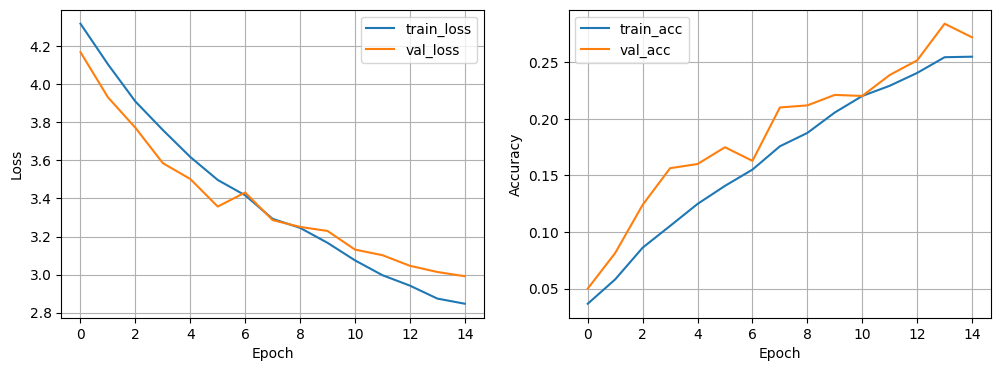

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label="train_loss")
plt.plot(val_losses, label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(train_accs, label="train_acc")
plt.plot(val_accs, label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


#Шаг 9. Примеры предсказаний

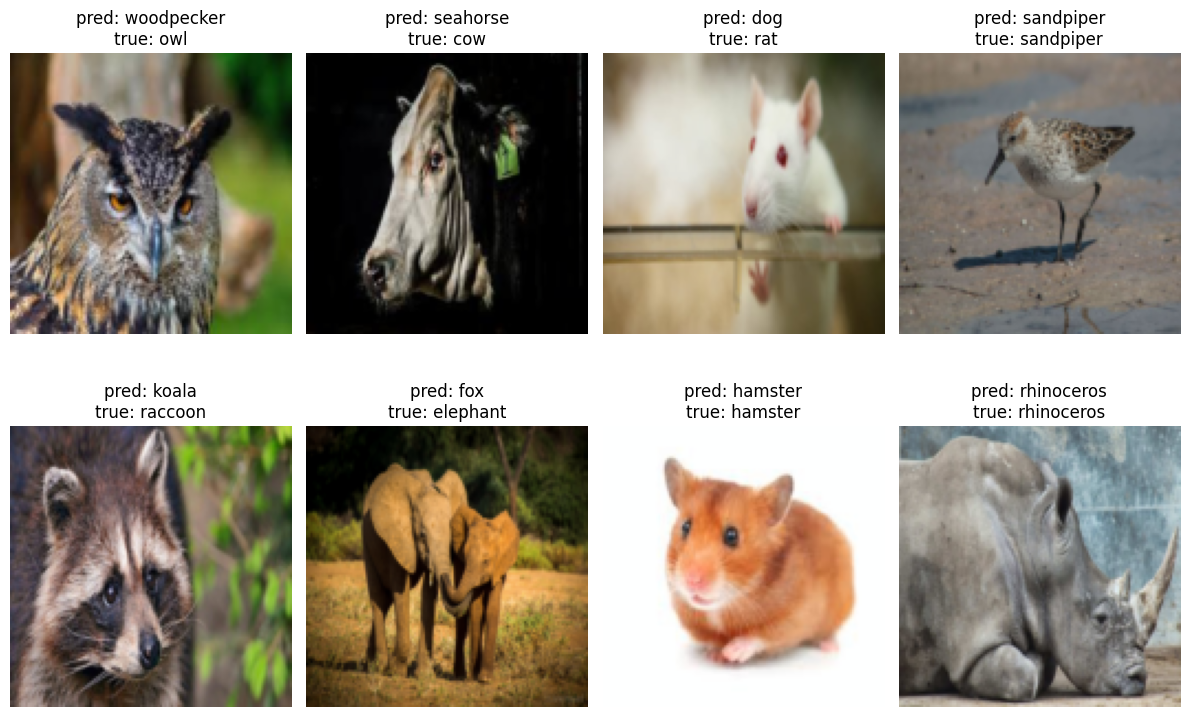

In [ ]:
class_names = full_dataset.classes

def imshow(inp, title=None):
    inp = inp.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis("off")

model.eval()
images, labels = next(iter(val_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = outputs.max(1)

plt.figure(figsize=(12, 8))
for i in range(8):
    ax = plt.subplot(2, 4, i+1)
    imshow(images[i])
    ax.set_title(f"pred: {class_names[preds[i]]}\ntrue: {class_names[labels[i]]}")
plt.tight_layout()
plt.show()


#Шаг 10. Сохранение model.pth в нашу папку /111/archive

In [ ]:
def save_model(model, path="model.pth"):
    model.eval()
    model.cpu()
    example_input = torch.randn(1, 3, 32, 32)
    traced_model = torch.jit.trace(model, (example_input,))
    torch.jit.save(traced_model, path)
    print(f"Модель сохранена в {path}")

    test_load = torch.jit.load(path)
    with torch.no_grad():
        output = test_load(example_input)
    print(f"Проверка пройдена! Output shape: {output.shape}")
    return True

model_path = os.path.join(base_dir, "model.pth")  # Сохраняем в /111/archive/model.pth
save_model(model, model_path)


Модель сохранена в /content/drive/MyDrive/111/archive/model.pth
Проверка пройдена! Output shape: torch.Size([1, 90])


True